In [12]:
from qiskit import *
from qiskit_aer import AerSimulator, StatevectorSimulator
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
import matplotlib.pyplot as plt

# Data generation

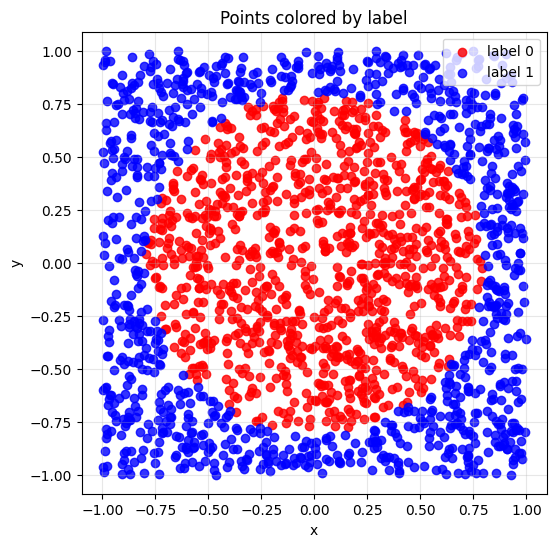

points in label 0: 1010
points in label 1: 990


In [13]:
n = 2000
points = np.random.rand(n, 2) * 2 - 1
labels = [0 if x**2 + y**2 < 2/np.pi else 1 for x, y in points]


import matplotlib.pyplot as plt

arr = np.array(points)
lbl = np.array(labels)

plt.figure(figsize=(6, 6))
plt.scatter(arr[lbl == 0, 0], arr[lbl == 0, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(arr[lbl == 1, 0], arr[lbl == 1, 1], c="blue", label="label 1", alpha=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Points colored by label")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("points in label 0:", np.sum(lbl == 0))
print("points in label 1:", np.sum(lbl == 1))

In [14]:

test_size = 0.2
rng = np.random.default_rng(42)

indices = rng.permutation(len(arr))
split_idx = int(len(arr) * (1 - test_size))

train_idx, test_idx = indices[:split_idx], indices[split_idx:]

X_train, X_test = arr[train_idx], arr[test_idx]
y_train, y_test = lbl[train_idx], lbl[test_idx]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (1600, 2) y_train: (1600,)
X_test : (400, 2) y_test : (400,)


In [15]:
def U_su2(q, theta, omega, x, qubit):
    x3d = [x[0], x[1], 0] # Add a third dimension with value 0
    # phi_i = theta_i + w_i * x_i
    val_0 = theta[0] + omega[0] * x3d[0]
    val_1 = theta[1] + omega[1] * x3d[1]
    val_2 = theta[2] + omega[2] * x3d[2]
    
    q.u(val_0, val_1, val_2, qubit)

In [ ]:
rc = 4

def create_circuit(x, theta, omega, measure=True):
    qc = QuantumCircuit(1)
    for i in range(rc):
        #qc.h(0)
        U_su2(qc, theta[i], omega[i], x, 0)
    if measure:
        qc.measure_all()
    return qc


In [17]:
theta = [[1,1,1] for _ in range(rc)]
omega = [[1,1,1] for _ in range(rc)]
qc =create_circuit(X_train[0], theta, omega)
qc.draw()

┌───┐┌─────────────────────┐┌───┐┌─────────────────────┐┌───┐»
     q: ┤ H ├┤ U(1.7969,0.53324,1) ├┤ H ├┤ U(1.7969,0.53324,1) ├┤ H ├»
        └───┘└─────────────────────┘└───┘└─────────────────────┘└───┘»
meas: 1/═════════════════════════════════════════════════════════════»
                                                                     »
«        ┌─────────────────────┐┌───┐┌─────────────────────┐ ░ ┌─┐
«     q: ┤ U(1.7969,0.53324,1) ├┤ H ├┤ U(1.7969,0.53324,1) ├─░─┤M├
«        └─────────────────────┘└───┘└─────────────────────┘ ░ └╥┘
«meas: 1/═══════════════════════════════════════════════════════╩═
«                                                               0

In [18]:
sv_sim = StatevectorSimulator()

def get_prob_zero(circuit):
    """
    Retourne la probabilité d'état |0⟩ via simulation statevector (pas de shots).
    """
    qc_no_meas = create_circuit.__wrapped__(circuit) if hasattr(create_circuit, '__wrapped__') else circuit
    sv = sv_sim.run(transpile(qc_no_meas, sv_sim)).result().get_statevector()
    return float(abs(sv[0])**2)

def cost_function(theta, omega, X_train, y_train):
    """
    Calcule le coût en batch : un seul transpile + run pour tous les points.
    """
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()

    total_cost = 0.0
    for i, y in enumerate(y_train):
        sv = results.get_statevector(i)
        prob_0 = float(abs(sv[0])**2)
        predicted_prob = prob_0 if y == 0 else (1 - prob_0)
        total_cost += (1 - predicted_prob)
    return total_cost / len(y_train)


In [19]:
def cost_function_weighted(params, X_train, y_train, rc):
    # 1. Extraction des paramètres (3*rc pour theta, 3*rc pour omega, 2 pour alpha)
    # On s'assure que rc est un entier
    rc = int(rc)
    split_theta = 3 * rc
    split_omega = 6 * rc
    
    theta = params[:split_theta].reshape(rc, 3)
    omega = params[split_theta:split_omega].reshape(rc, 3)
    alphas = params[split_omega:] # alpha_0 et alpha_1

    # 2. Simulation des circuits en batch (sans mesures pour le Statevector)
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X_train]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()

    total_cost = 0.0
    for i, y_target in enumerate(y_train):
        # Récupération du vecteur d'état final |psi>
        sv = results.get_statevector(i)
        
        # Calcul des fidélités F_c = |<target_c|psi>|^2
        # Pour la classe 0 (Nord) : |<0|psi>|^2 = abs(sv[0])^2
        f0 = np.abs(sv.data[0])**2
        # Pour la classe 1 (Sud) : |<1|psi>|^2 = abs(sv[1])^2
        f1 = np.abs(sv.data[1])**2
        
        f_measures = [f0, f1]

        # Overlaps attendus Y_c (Eq. 247/248)
        # Classe cible = 1, Classe opposée = 0 (car orthogonales)
        y_expected = [1.0, 0.0] if y_target == 0 else [0.0, 1.0]

        # Somme pondérée (alpha_c * F_c - Y_c)^2
        sample_error = 0.0
        for c in range(2):
            sample_error += (alphas[c] * f_measures[c] - y_expected[c])**2
        
        total_cost += sample_error

    # 1/2 * moyenne (Eq. 9)
    return 0.5 * (total_cost / len(y_train))

In [20]:
import numpy as np
from scipy.optimize import minimize



def unpack_params(params, rc):
    split_theta = 3 * rc
    split_omega = 6 * rc
    theta = params[:split_theta].reshape(rc, 3)
    omega = params[split_theta:split_omega].reshape(rc, 3)
    alphas = params[split_omega:]
    return theta, omega, alphas

def optimize_parameters(X_train, y_train, rc, maxiter=80, seed=42):
        
    rng = np.random.default_rng(seed)
    init = rng.uniform(-np.pi, np.pi, size=6 * rc+2) # 3*rc pour theta, 3*rc pour omega, 2 pour alpha

    cache = {"cost": None}
    cost_history = []
    step = {"k": 0}

    def objective(params):
        cost = cost_function_weighted(params, X_train, y_train, rc)
        cache["cost"] = cost  # mémorise le dernier coût calculé
        return cost

    def cb(xk):
        step["k"] += 1
        cost_history.append(cache["cost"])  # lu depuis le cache, sans recalculer
        print(f"Step {step['k']:03d} | cost = {cache['cost']:.6f}")

    res = minimize(
        objective,
        init,
        method="COBYLA",
        callback=cb,
        options={"maxiter": maxiter}
    )

    theta_opt, omega_opt, alphas_opt = unpack_params(res.x, rc)
    print(f"Final cost = {res.fun:.6f}")
    return theta_opt, omega_opt, res, cost_history


In [21]:
def predict_batch(X, theta, omega):
    """
    Prédit les labels pour tous les points X en un seul appel sim.run.
    """
    circuits = [create_circuit(x, theta, omega, measure=False) for x in X]
    compiled = transpile(circuits, sv_sim)
    results = sv_sim.run(compiled).result()
    preds = []
    for i in range(len(X)):
        sv = results.get_statevector(i)
        prob_0 = float(abs(sv[0])**2)
        preds.append(0 if prob_0 >= 0.5 else 1)
    return np.array(preds)

def evaluate_metrics(X, y, theta, omega, positive_label=1):
    y_pred = predict_batch(X, theta, omega)
    tp = np.sum((y_pred == positive_label) & (y == positive_label))
    fp = np.sum((y_pred == positive_label) & (y != positive_label))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    accuracy = np.mean(y_pred == y)
    return precision, accuracy, y_pred

# --- train + test ---
theta_opt, omega_opt, res, cost_history = optimize_parameters(X_train, y_train, rc, maxiter=300)
precision_test, accuracy_test, y_pred = evaluate_metrics(X_test, y_test, theta_opt, omega_opt)

print("Final train cost:", res.fun)
print("Test precision:", precision_test)
print("Test accuracy: ", accuracy_test)


Step 001 | cost = 1.230657
Step 002 | cost = 1.369137
Step 003 | cost = 1.302379
Step 004 | cost = 1.135457
Step 005 | cost = 1.192314
Step 006 | cost = 1.356456
Step 007 | cost = 1.575117
Step 008 | cost = 1.116882
Step 009 | cost = 1.371244
Step 010 | cost = 1.158203
Step 011 | cost = 1.473926
Step 012 | cost = 1.116882
Step 013 | cost = 1.174102
Step 014 | cost = 1.109419
Step 015 | cost = 1.233274
Step 016 | cost = 1.109419
Step 017 | cost = 1.122128
Step 018 | cost = 1.151814
Step 019 | cost = 1.109419
Step 020 | cost = 1.117840
Step 021 | cost = 1.168941
Step 022 | cost = 1.109419
Step 023 | cost = 1.195991
Step 024 | cost = 1.109419
Step 025 | cost = 1.109419
Step 026 | cost = 2.213511
Step 027 | cost = 0.933644
Step 028 | cost = 0.484218
Step 029 | cost = 0.521230
Step 030 | cost = 0.494249
Step 031 | cost = 0.462845
Step 032 | cost = 0.475414
Step 033 | cost = 0.493272
Step 034 | cost = 0.443252
Step 035 | cost = 0.434357
Step 036 | cost = 0.435225
Step 037 | cost = 0.572418
S

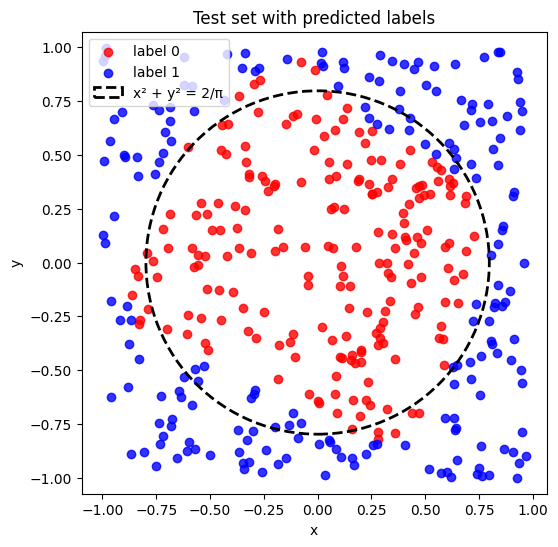

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(X_test[y_pred == 0][:, 0], X_test[y_pred == 0][:, 1], c="red", label="label 0", alpha=0.8)
plt.scatter(X_test[y_pred == 1][:, 0], X_test[y_pred == 1][:, 1], c="blue", label="label 1", alpha=0.8)
r = np.sqrt(2 / np.pi)
circle = plt.Circle((0, 0), r, color="black", fill=False, linestyle="--", linewidth=2, label="x² + y² = 2/π")
plt.gca().add_patch(circle)
plt.axis("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Test set with predicted labels")
plt.legend()
plt.show()

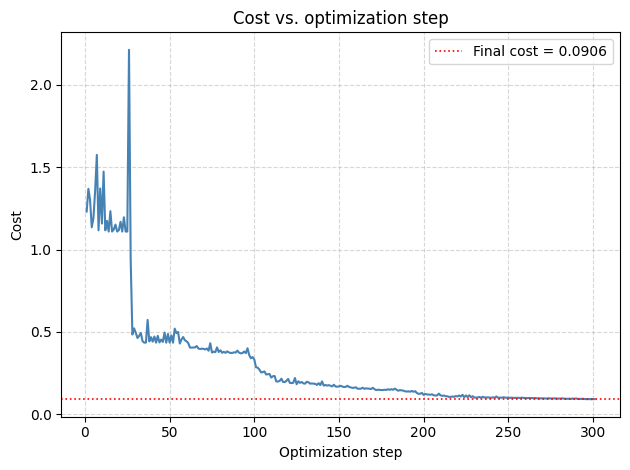

In [26]:
ax1 = plt.subplot(1, 1, 1)
ax1.plot(range(1, len(cost_history) + 1), cost_history, color="steelblue", linewidth=1.5)
ax1.set_xlabel("Optimization step")
ax1.set_ylabel("Cost")
ax1.set_title("Cost vs. optimization step")
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.axhline(res.fun, color="red", linestyle=":", linewidth=1.2, label=f"Final cost = {res.fun:.4f}")
ax1.legend()


plt.tight_layout()
plt.show()
